In [2]:
import pandas as pd
import numpy as np

from IPython.display import Image, display

# Determining wave parameters

Before going into lab, I need to have a plan for which waves to run and analyze. I am interested in linear waves, and will therefore use linear wave theory when performing a parameter study. 

The requirements are:
* $kH \approx \le 1$ - Waves which classify as shallow to intermediate waves.
* $ak \le 0.1$ - Wave steepness, waves which are linear.

$ak$ can be interpreted as a measure of how significant non-linear effects are. So $ak=0.1$ means that the next order correction, or that the second order effects contribute $0.1^2 = 1\%$ to the first-order linear solution. Linear theory errors are small, to the order of $1\%$ or less. 

I will start with running long waves on shallow water (those who feel the bottom more) and move on to shorter waves until there is no more damping visible. Some damping is either way expected due to the walls of the tank. And then do the same for deeper and deeper water.

There are 4 wave gauges in the lab which can be mounted to racks above the tank. To get an impression of what happens along the tank, I want to make a synthetic array of the wave gauges. If I place the four probes after one another with a fixed distance between them, then run the the waves. I can move the rack some distance downstream and rerun the same waves. Then I get an impression of what happens as the waves flow along the tank. 

Maxime did this, and he used 5 positions of the 4 probes as seen below. The stipled lines indicates where the region of plates would be. 

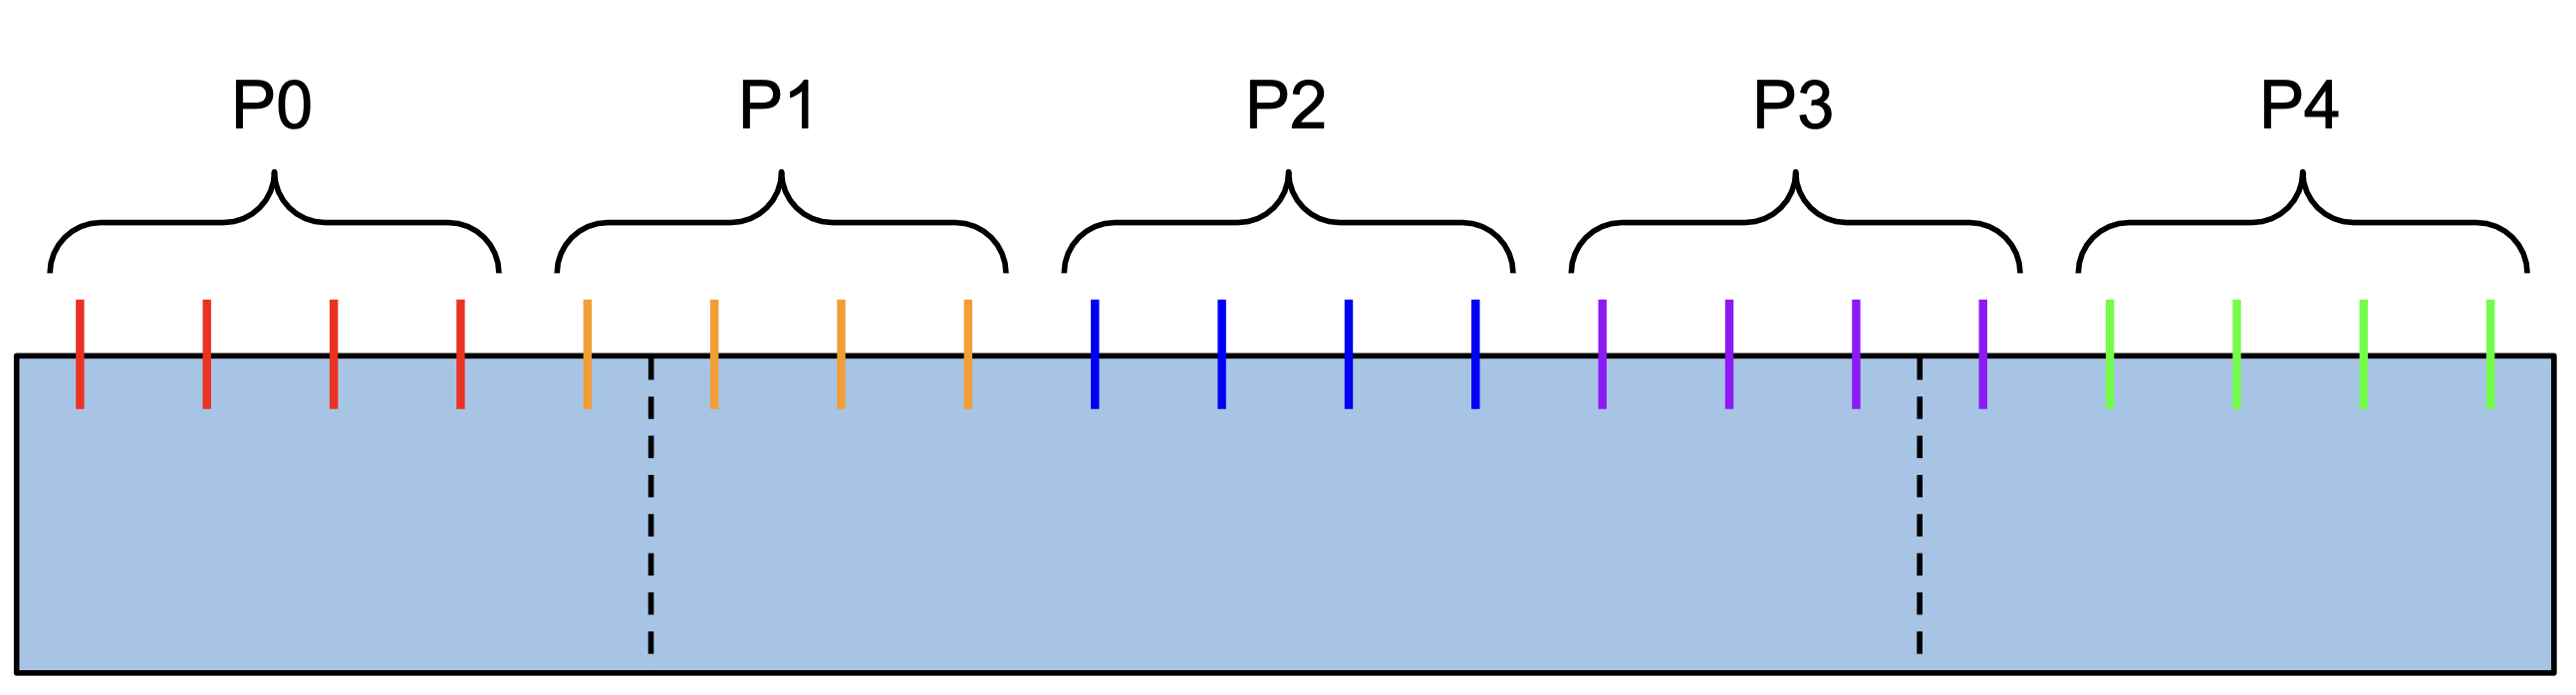

In [3]:
image_path = '/Users/kjesta/Desktop/Master prosjekt/Figurer/probe_positions.png'
display(Image(filename=image_path))

### Experiment round 2 - no plates
For each probe positions in $P_0, P_1, P_2, P_3, P_4$, for each water depth $(0.2 m, 0.3 m, 0.4 m)$: run waves a-c 3 times.
Where wave a-c has decreasing wavelength. Expect to see more damping for longer waves.

### Experiments round 2 - with plates
For each probe positions in $P_0, P_1, P_2, P_3, P_4$, for each water depth $(0.2 m, 0.3 m, 0.4 m)$: run waves a-c 3 times.
Where wave a-c has decreasing wavelength. Expect to see more damping for longer waves.

### Questions
* Is it benefitial to have 5 probe positions, or could 4 be enough?

In [7]:
depths = [0.2, 0.3, 0.4]
ak_max = 0.1
kH_max = 1

g = 9.81

# Number of experiments per depth
num = 3

table_data = []

for H in depths:
    # maximum wave number for given depth
    k_max = kH_max/H
    # guessing on a minimum wave number
    k_min = 2
    # wave numbers
    k_values = np.linspace(k_min, k_max, num)

    for i, k in enumerate(k_values):
        # wavelength
        lam = 2 * np.pi / k 
        # max amplitude for linear waves
        a_max = ak_max / k
        kH = k * H
        ak = k * a_max
        # angular frequency
        # from dispersion relation
        omega = np.sqrt(g*k*np.tanh(kH))
        # frequency
        f = omega/(2*np.pi)
        # wave period
        T = 1/f
        # making a table with labels
        exp_label = f"{depths.index(H)+1}{chr(97+i)}"
        table_data.append([exp_label, H, lam, k, a_max, omega, f, T, kH, ak])

df = pd.DataFrame(table_data, columns=["Exp", "H (m)", "λ (m)", "k (1/m)", "a_max (m)","ω (rad/s)", "f (1/s)", "T (s)","kH", "ak"])

df

,Exp,H (m),λ (m),k (1/m),a_max (m),ω (rad/s),f (1/s),T (s),kH,ak
0,1a,0.2,3.141593,2.000000,0.050000,2.730311,0.434543,2.301271,0.4,0.1
1,1b,0.2,1.795196,3.500000,0.028571,4.555323,0.725002,1.379306,0.7,0.1
2,1c,0.2,1.256637,5.000000,0.020000,6.111971,0.972750,1.028013,1.0,0.1
3,2a,0.3,3.141593,2.000000,0.050000,3.246061,0.516627,1.935634,0.6,0.1
4,2b,0.3,2.356194,2.666667,0.037500,4.167877,0.663338,1.507526,0.8,0.1
5,2c,0.3,1.884956,3.333333,0.030000,4.990404,0.794247,1.259054,1.0,0.1
6,3a,0.4,3.141593,2.000000,0.050000,3.609488,0.574468,1.740742,0.8,0.1
7,3b,0.4,2.792527,2.250000,0.044444,3.976240,0.632838,1.580183,0.9,0.1
8,3c,0.4,2.513274,2.500000,0.040000,4.321816,0.687838,1.453830,1.0,0.1
